Siddhant Nikam
I051
ATML Lab3|




#UNDERSTANDING AUTOENCODERS

Imports and Data Preparation

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [ ]:
# 1. Define transformation
transform = transforms.ToTensor()

# 2. Download and load the datasets
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# 3. Create DataLoaders to batch the data efficiently
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# 4. Set device to GPU if available for faster training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

100%|██████████| 9.91M/9.91M [00:00<00:00, 59.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.69MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.90MB/s]


Defining Autoencoder Architecture

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, bottleneck_size, hidden_layers):
        super(Autoencoder, self).__init__()

        # --- ENCODER ---
        enc_layers = []
        in_features = 28 * 28 # MNIST images are 28x28 pixels

        for h in hidden_layers:
            enc_layers.append(nn.Linear(in_features, h))
            enc_layers.append(nn.ReLU()) # Non-linear activation
            in_features = h

        enc_layers.append(nn.Linear(in_features, bottleneck_size))
        enc_layers.append(nn.ReLU())
        self.encoder = nn.Sequential(*enc_layers)

        # --- DECODER ---
        dec_layers = []
        in_features = bottleneck_size

        # Build decoder layers in reverse order of encoder
        for h in reversed(hidden_layers):
            dec_layers.append(nn.Linear(in_features, h))
            dec_layers.append(nn.ReLU())
            in_features = h

        dec_layers.append(nn.Linear(in_features, 28 * 28))
        dec_layers.append(nn.Sigmoid()) # Squashes output to 0-1 for BCE Loss
        self.decoder = nn.Sequential(*dec_layers)

    def forward(self, x):
        # Flatten the 2D image into a 1D vector (batch_size, 784)
        x = x.view(-1, 28 * 28)
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        # Reshape the 1D vector back into a 2D image format (batch_size, 1, 28, 28)
        return decoded.view(-1, 1, 28, 28)

Training Loop

In [ ]:
def train_model(model, train_loader, criterion, optimizer, epochs=3):
    model.train() # Set model to training mode

    for epoch in range(epochs):
        train_loss = 0.0

        # loop through batches
        for data, _ in train_loader:
            data = data.to(device)

            # 1. Clear old gradients
            optimizer.zero_grad()

            # 2. Forward pass: Generate reconstructed images
            outputs = model(data)

            # 3. Calculate BCE loss (comparing reconstructed vs. original)
            loss = criterion(outputs, data)

            # 4. Backward pass: Calculate gradients
            loss.backward()

            # 5. Update weights
            optimizer.step()

            # Keep track of total loss
            train_loss += loss.item() * data.size(0)

        # Average loss for the epoch
        train_loss = train_loss / len(train_loader.dataset)
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}")

Evaluation

In [ ]:
def evaluate_model(model, test_loader, criterion):
    model.eval() # Set model to evaluation mode
    test_loss = 0.0

    with torch.no_grad(): # Turn off gradient tracking
        for data, _ in test_loader:
            data = data.to(device)
            outputs = model(data)

            # Calculate the reconstruction error using BCE
            loss = criterion(outputs, data)
            test_loss += loss.item() * data.size(0)

    # Return average reconstruction error
    return test_loss / len(test_loader.dataset)

In [ ]:
# Setup our Loss function
criterion = nn.BCELoss()

# Define parameters to test
bottleneck_sizes = [16, 64]
hidden_layer_configs = [[128], [256, 128]]
learning_rates = [1e-2, 1e-3]

print(f"{'Bottleneck':<12} | {'Hidden Layers':<20} | {'LR':<10} | {'Test BCE Error'}")

for b_size in bottleneck_sizes:
    for h_layers in hidden_layer_configs:
        for lr in learning_rates:

            # Initialize Model
            model = Autoencoder(bottleneck_size=b_size, hidden_layers=h_layers).to(device)

            # Initialize Optimizer
            optimizer = optim.Adam(model.parameters(), lr=lr)

            # Train and Evaluate
            train_model(model, train_loader, criterion, optimizer, epochs=3)
            test_error = evaluate_model(model, test_loader, criterion)

            # Print results for this combination
            print(f"{b_size:<12} | {str(h_layers):<20} | {lr:<10} | {test_error:.4f}")

Bottleneck   | Hidden Layers        | LR         | Test BCE Error
Epoch 1/3 - Train Loss: 0.1737
Epoch 2/3 - Train Loss: 0.1462
Epoch 3/3 - Train Loss: 0.1431
16           | [128]                | 0.01       | 0.1418
Epoch 1/3 - Train Loss: 0.2218
Epoch 2/3 - Train Loss: 0.1473
Epoch 3/3 - Train Loss: 0.1359
16           | [128]                | 0.001      | 0.1305
Epoch 1/3 - Train Loss: 0.1956
Epoch 2/3 - Train Loss: 0.1620
Epoch 3/3 - Train Loss: 0.1577
16           | [256, 128]           | 0.01       | 0.1560
Epoch 1/3 - Train Loss: 0.2228
Epoch 2/3 - Train Loss: 0.1455
Epoch 3/3 - Train Loss: 0.1288
16           | [256, 128]           | 0.001      | 0.1222
Epoch 1/3 - Train Loss: 0.1635
Epoch 2/3 - Train Loss: 0.1105
Epoch 3/3 - Train Loss: 0.1002
64           | [128]                | 0.01       | 0.0966
Epoch 1/3 - Train Loss: 0.2148
Epoch 2/3 - Train Loss: 0.1285
Epoch 3/3 - Train Loss: 0.1118
64           | [128]                | 0.001      | 0.1048
Epoch 1/3 - Train Loss: 0.19

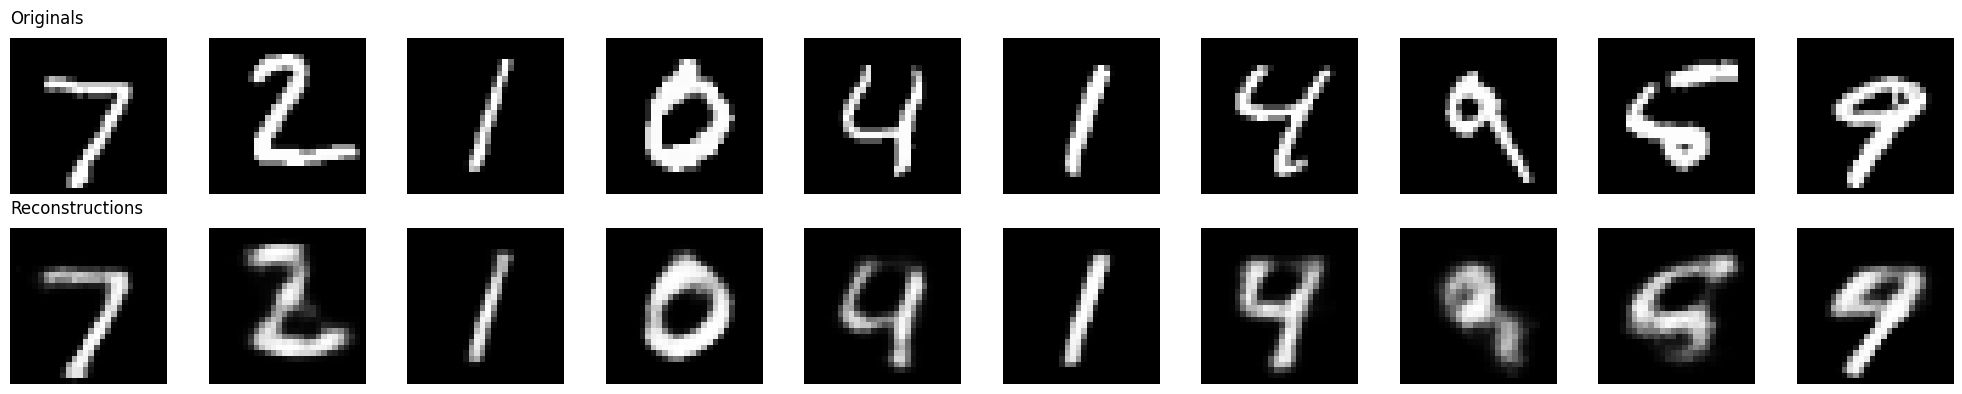

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_reconstructions(model, test_loader, num_images=10):
    model.eval()

    # 1. Grab a single batch of test images
    dataiter = iter(test_loader)
    images, _ = next(dataiter)
    images = images.to(device)

    # 2. Generate reconstructions
    with torch.no_grad():
        reconstructed = model(images)

    # 3. Move to CPU and convert to numpy for plotting
    images = images.cpu().numpy()
    reconstructed = reconstructed.cpu().numpy()

    # 4. Plot original vs. reconstructed
    fig, axes = plt.subplots(nrows=2, ncols=num_images, figsize=(20, 4))

    for i in range(num_images):
        # Top Row: Original Images
        axes[0, i].imshow(np.squeeze(images[i]), cmap='gray')
        axes[0, i].axis('off')

        # Bottom Row: Reconstructed Images
        axes[1, i].imshow(np.squeeze(reconstructed[i]), cmap='gray')
        axes[1, i].axis('off')

    axes[0, 0].set_title("Originals", loc='left', pad=10)
    axes[1, 0].set_title("Reconstructions", loc='left', pad=10)
    plt.tight_layout()
    plt.show()

# Just run this line using your currently trained model and test_loader
visualize_reconstructions(model, test_loader)

#APPLICATION - CREDIT CARD FRAUD DETECTION

Loading and Preparing actual CSV dataset

In [ ]:
import pandas as pd
print("Loading dataset...")
# Make sure 'creditcard.csv' is in your current directory
df = pd.read_csv('creditcard.csv')

# Separate the data into Normal (Class 0) and Fraud (Class 1)
normal_df = df[df['Class'] == 0].drop(columns=['Class'])
fraud_df = df[df['Class'] == 1].drop(columns=['Class'])

print(f"Found {len(normal_df)} normal transactions and {len(fraud_df)} fraudulent transactions.")

Loading dataset...
Found 284315 normal transactions and 492 fraudulent transactions.


Scaling the dataset

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

# Real tabular data needs standardizing so large numbers (like Amount)
# don't overpower small numbers (like the PCA V-columns).
scaler = StandardScaler()

# CRITICAL: We ONLY fit the scaler to the normal data!
normal_data = scaler.fit_transform(normal_df)
# We transform the fraud data based on the normal data's baseline
fraud_data = scaler.transform(fraud_df)

# Convert to PyTorch Tensors
normal_tensor = torch.FloatTensor(normal_data)
fraud_tensor = torch.FloatTensor(fraud_data)

# Create a DataLoader for efficient mini-batch training
batch_size = 256
normal_dataset = TensorDataset(normal_tensor, normal_tensor) # Target is the input itself
train_loader = DataLoader(normal_dataset, batch_size=batch_size, shuffle=True)

Defining Architecture

In [ ]:
class RealFraudAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super(RealFraudAutoencoder, self).__init__()

        # The Kaggle dataset has 30 features (Time, Amount, and V1-V28)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 3), # Compressing 30 dimensions down to a bottleneck of 3
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Linear(3, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim)
            # No Sigmoid because we used StandardScaler (data has negative values)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = normal_df.shape[1] # Should be 30
model = RealFraudAutoencoder(input_dim).to(device)

Training

In [ ]:
# We use Mean Squared Error (MSE) because this is continuous, unbounded tabular data
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10 # 10 epochs on 284k rows is plenty to learn the baseline
print("\nTraining Autoencoder on normal transactions...")

model.train()
for epoch in range(epochs):
    train_loss = 0.0
    for batch_data, _ in train_loader:
        batch_data = batch_data.to(device)

        optimizer.zero_grad()
        outputs = model(batch_data)
        loss = criterion(outputs, batch_data)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * batch_data.size(0)

    avg_loss = train_loss / len(train_loader.dataset)
    print(f"Epoch {epoch+1}/{epochs} - Train MSE Loss: {avg_loss:.4f}")


Training Autoencoder on normal transactions...
Epoch 1/10 - Train MSE Loss: 0.8293
Epoch 2/10 - Train MSE Loss: 0.7304
Epoch 3/10 - Train MSE Loss: 0.7069
Epoch 4/10 - Train MSE Loss: 0.6890
Epoch 5/10 - Train MSE Loss: 0.6724
Epoch 6/10 - Train MSE Loss: 0.6586
Epoch 7/10 - Train MSE Loss: 0.6493
Epoch 8/10 - Train MSE Loss: 0.6440
Epoch 9/10 - Train MSE Loss: 0.6402
Epoch 10/10 - Train MSE Loss: 0.6368


Evaluation and Calculating Reconstruction Error


In [ ]:
# --- ADD THIS TO SEE THE RESULTS IN YOUR CONSOLE ---
print("-" * 45)
print("REAL-WORLD RECONSTRUCTION ERROR SUMMARY")
print("-" * 45)
print(f"Average Normal Error: {normal_mse.mean():.4f}")
print(f"Average Fraud Error:  {fraud_mse.mean():.4f}\n")

print(f"Highest Normal Error: {normal_mse.max():.4f}")
print(f"Lowest Fraud Error:   {fraud_mse.min():.4f}")
print("-" * 45)

---------------------------------------------
REAL-WORLD RECONSTRUCTION ERROR SUMMARY
---------------------------------------------
Average Normal Error: 0.6333
Average Fraud Error:  22.9697

Highest Normal Error: 528.3279
Lowest Fraud Error:   0.1224
---------------------------------------------


Visualization

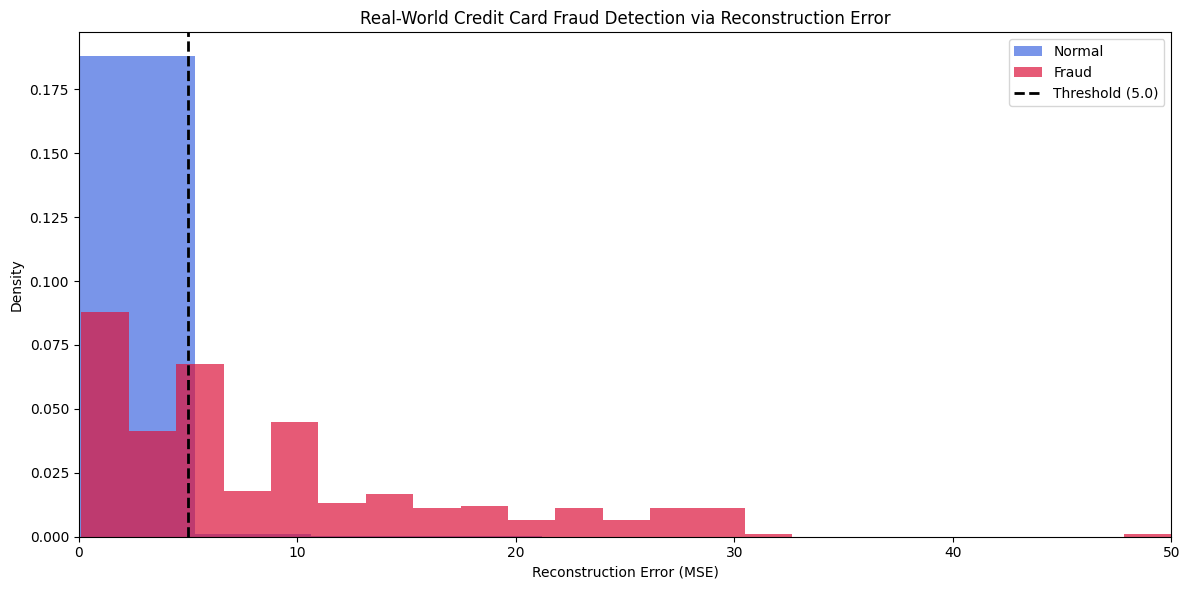

In [ ]:
plt.figure(figsize=(12, 6))

# Plot normal transaction errors
plt.hist(normal_mse, bins=100, alpha=0.7, color='royalblue', label='Normal', density=True)
# Plot fraud transaction errors
plt.hist(fraud_mse, bins=100, alpha=0.7, color='crimson', label='Fraud', density=True)

# Because a few fraud transactions might have massive errors,
# we limit the X-axis so the chart remains readable.
plt.xlim(0, 50)

# Example Threshold Line
threshold = 5.0
plt.axvline(x=threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold ({threshold})')

plt.title('Real-World Credit Card Fraud Detection via Reconstruction Error')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

Inference

In [ ]:
# ==========================================
# 1. The Inference Function
# ==========================================
def check_transaction(raw_transaction_df, trained_model, fitted_scaler, threshold=5.0):
    """
    Takes a raw transaction, scales it, passes it through the Autoencoder,
    and flags it if the reconstruction error exceeds the threshold.
    """
    # 1. Preprocess: Scale the data!
    # We use .transform() so it scales based on the training data's baseline.
    scaled_data = fitted_scaler.transform(raw_transaction_df)

    # 2. Convert to PyTorch Tensor and move to device
    tensor_data = torch.FloatTensor(scaled_data).to(device)

    # 3. Put the model in evaluation mode
    trained_model.eval()

    # 4. Run the data through the Autoencoder
    with torch.no_grad():
        reconstruction = trained_model(tensor_data)

        # Calculate the Mean Squared Error for this single transaction
        mse_loss = torch.mean((tensor_data - reconstruction)**2).item()

    # 5. Apply Business Logic (Threshold)
    print("-" * 45)
    if mse_loss > threshold:
        print(f"🚨 ALERT: Fraudulent Transaction Detected!")
        print(f"   Reconstruction Error: {mse_loss:.4f} (Threshold: {threshold})")
        print("   Action: Block transaction and flag account.")
    else:
        print(f"✅ Normal Transaction Approved.")
        print(f"   Reconstruction Error: {mse_loss:.4f} (Threshold: {threshold})")
        print("   Action: Process transaction.")
    print("-" * 45)

# ==========================================
# 2. Testing with Real Data
# ==========================================
# Let's grab one real normal transaction and one real fraud transaction
# straight from the dataframes we created in Step 1.
# (random_state ensures we grab the exact same sample every time we run this)

sample_normal_transaction = normal_df.sample(1, random_state=42)
sample_fraud_transaction = fraud_df.sample(1, random_state=42)

print("\n>>> INFERENCE TEST 1: Feeding a known NORMAL transaction...")
check_transaction(sample_normal_transaction, model, scaler, threshold=5.0)

print("\n>>> INFERENCE TEST 2: Feeding a known FRAUDULENT transaction...")
check_transaction(sample_fraud_transaction, model, scaler, threshold=5.0)


>>> INFERENCE TEST 1: Feeding a known NORMAL transaction...
---------------------------------------------
✅ Normal Transaction Approved.
   Reconstruction Error: 0.1619 (Threshold: 5.0)
   Action: Process transaction.
---------------------------------------------

>>> INFERENCE TEST 2: Feeding a known FRAUDULENT transaction...
---------------------------------------------
🚨 ALERT: Fraudulent Transaction Detected!
   Reconstruction Error: 69.2041 (Threshold: 5.0)
   Action: Block transaction and flag account.
---------------------------------------------


Inference with User Inputs

In [ ]:
# 1. Create your custom 30-feature transaction list
# Format: [Time, V1, V2 ... V28, Amount]
my_custom_data = [[
    406.0,  # Time (seconds)
    -2.3, 1.1, -3.5, 2.2, -1.4, -0.8, -2.1, 1.2, -1.9, -2.0, # V1 to V10
    3.1, -4.2, 0.3, -2.4, -0.5, -1.6, -3.7, 0.8, 1.9, -2.0,  # V11 to V20
    1.2, 0.4, -1.3, 0.1, -0.5, 0.6, -0.2, 0.1,               # V21 to V28
    999.99  # Amount (dollars)
]]

# 2. Convert it into a Pandas DataFrame
# (The scaler expects the exact same column names it saw during training)
custom_df = pd.DataFrame(my_custom_data, columns=normal_df.columns)

# 3. Feed it to your inference function
print("\n>>> INFERENCE TEST 3: Testing your custom manual transaction...")
check_transaction(custom_df, model, scaler, threshold=5.0)


>>> INFERENCE TEST 3: Testing your custom manual transaction...
---------------------------------------------
✅ Normal Transaction Approved.
   Reconstruction Error: 4.3107 (Threshold: 5.0)
   Action: Process transaction.
---------------------------------------------
